# Analyse the natural groups in the data - Standardize columns properly and treat missing values.

I'm going to  run t-SNE vidualisation over session_data_full.csv

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler
import seaborn as sns



import os
import core.constants as c
from core.utils import save_df_as_table_image

session_data_full = pd.read_csv(c.RICKD_SESSION_DATA_FULL_CLEANED_FILE)
session_data_full

,id,sub_id,datestring,filename,speed_r,age,Height,Weight,Gender,DominantLeg,...,injury_desc,injury2_desc,injury_name,injury2_name,injured_joint_code,injured_joint2_code,injured_side_code,injured_side2_code,has_no_injury,is_injured
0,100433_20101005T132240,100433,2010-10-05 13:22:40,20101005t132240.json,1.610861,53.0,NaN,NaN,NaN,NaN,...,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,knee,no_injury,right,right,False,True
1,100434_20101117T132240,100434,2010-11-17 13:22:40,20101117t132240.json,2.237294,51.0,NaN,NaN,female,NaN,...,Breakdown and gradual loss of spinal disc cush...,No injury has been diagnosed.,disc degeneration,no injury,lumbar_spine,no_injury,bilateral,right,False,True
2,100537_20120703T102550,100537,2012-07-03 10:25:50,20120703t102550.json,2.127441,NaN,173.1,67.6,female,right,...,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,hip_pelvis,no_injury,right,right,False,True
3,100560_20120717T103748,100560,2012-07-17 10:37:48,20120717t103748.json,2.657365,33.0,179.3,83.0,female,right,...,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,right,right,True,False
4,101481_20120717T105021,101481,2012-07-17 10:50:21,20120717t105021.json,2.625088,32.0,176.3,58.6,female,NaN,...,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827,200986_20150312T143944,200986,2015-03-12 14:39:44,20150312t143944.json,4.876998,20.0,174.0,56.8,female,right,...,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,True,False
1828,200987_20150312T160840,200987,2015-03-12 16:08:40,20150312t160840.json,2.765022,50.0,164.0,60.0,female,right,...,Misalignment or imbalance of pelvic bones caus...,Painful friction of iliotibial band rubbing ov...,pelvic malalignment,itb syndrome,hip_pelvis,thigh,right,left,False,True
1829,201100_20150409T155915,201100,2015-04-09 15:59:15,20150409t155915.json,2.790966,52.0,170.0,80.0,male,right,...,Muscle fibers stretched or torn due to excessi...,Stretching or tearing of ligaments due to exce...,muscle strain,ligament sprain,lumbar_spine,ankle,bilateral,right,False,True
1830,201101_20150413T143152,201101,2015-04-13 14:31:52,20150413t143152.json,2.828602,21.0,162.0,65.5,male,right,...,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,True,False


In [2]:
# Create is_injured variable as the inverse of has_no_injury
session_data_full['is_injured'] = (~session_data_full["has_no_injury"]).astype(int)

# Split predictor and dependant variables
identifier_cols = [
    "id",
    "sub_id",
    "datestring",
    "filename"
]
dependant_variable_columns = [
    "injury_severity_code",
    "injury_severity_value",
    "injury_code",
    "injury2_code",
    "injury_desc",
    "injury2_desc",
    "injury_name",
    "injury2_name",
    "injured_joint_code",
    "injured_joint2_code",
    "injured_side_code",
    "injured_side2_code",
    "is_injured"
]
# Note, commented out column have been removed because they are not clean and
# do not add value in this state (i.e. RaceTime needs to be combined into a coefficient of performance)
predictor_columns = [
    "speed_r",
    "age",
    "Height",
    "Weight",
    "Gender",
    "DominantLeg",
    # "Activities",
    "Level",
    "YrsRunning",
    # "RaceDistance",
    # "RaceTimeHrs",
    # "RaceTimeMins",
    # "RaceTimeSecs",
    # "YrPR",
    "NumRaces",
    "l_step_width",
    "l_stride_rate",  # Es la inversa del length
    "l_stride_length", # Es comparado con la altura? -> Normalizar contra altura
    "l_swing_time",
    "l_stance_time",
    "l_pelvis_peak_drop_angle",
    "l_pelvis_drop_excursion",
    "l_ankle_df_peak_angle",
    "l_ankle_eve_peak_angle",
    "l_ankle_eve_percent_stance",
    "l_ankle_eve_excursion",
    "l_ankle_rot_peak_angle",
    "l_ankle_rot_excursion",
    "l_knee_flex_peak_angle",
    "l_knee_add_peak_angle",
    "l_knee_add_excursion",
    "l_knee_abd_peak_angle",
    "l_knee_abd_excursion",
    "l_knee_rot_peak_angle",
    "l_knee_rot_excursion",
    "l_hip_ext_peak_angle",
    "l_hip_add_peak_angle",
    "l_hip_add_excursion",
    "l_hip_rot_peak_angle",
    "l_hip_rot_excursion",
    "l_foot_prog_angle",
    "l_foot_ang_at_hs",
    "l_mhw_exc_from_to",
    "l_ankle_eve_peak_vel",
    "l_ankle_rot_peak_vel",
    "l_knee_abd_peak_vel",
    "l_knee_add_peak_vel",
    "l_hip_abd_peak_vel",
    "l_knee_rot_peak_vel",
    "l_hip_rot_peak_vel",
    "l_pronation_onset",
    "l_pronation_offset",
    "l_peak_hip_add_velocity",
    "l_peak_pelvic_drop_velocity",
    "l_vertical_oscillation",
    "r_step_width",
    "r_stride_rate",
    "r_stride_length",
    "r_swing_time",
    "r_stance_time",
    "r_pelvis_peak_drop_angle",
    "r_pelvis_drop_excursion",
    "r_ankle_df_peak_angle",
    "r_ankle_eve_peak_angle",
    "r_ankle_eve_percent_stance",
    "r_ankle_eve_excursion",
    "r_ankle_rot_peak_angle",
    "r_ankle_rot_excursion",
    "r_knee_flex_peak_angle",
    "r_knee_add_peak_angle",
    "r_knee_add_excursion",
    "r_knee_abd_peak_angle",
    "r_knee_abd_excursion",
    "r_knee_rot_peak_angle",
    "r_knee_rot_excursion",
    "r_hip_ext_peak_angle",
    "r_hip_add_peak_angle",
    "r_hip_add_excursion",
    "r_hip_rot_peak_angle",
    "r_hip_rot_excursion",
    "r_foot_prog_angle",
    "r_foot_ang_at_hs",
    "r_mhw_exc_from_to",
    "r_ankle_eve_peak_vel",
    "r_ankle_rot_peak_vel",
    "r_knee_abd_peak_vel",
    "r_knee_add_peak_vel",
    "r_hip_abd_peak_vel",
    "r_knee_rot_peak_vel",
    "r_hip_rot_peak_vel",
    "r_pronation_onset",
    "r_pronation_offset",
    "r_peak_hip_add_velocity",
    "r_peak_pelvic_drop_velocity",
    "r_vertical_oscillation",
]

Y = session_data_full.set_index("id")[dependant_variable_columns].copy()
X = session_data_full.set_index("id")[predictor_columns].copy()

print("X")
display(X.head())

print("Y")
display(Y.head())


X


,speed_r,age,Height,Weight,Gender,DominantLeg,Level,YrsRunning,NumRaces,l_step_width,...,r_knee_abd_peak_vel,r_knee_add_peak_vel,r_hip_abd_peak_vel,r_knee_rot_peak_vel,r_hip_rot_peak_vel,r_pronation_onset,r_pronation_offset,r_peak_hip_add_velocity,r_peak_pelvic_drop_velocity,r_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100433_20101005T132240,1.610861,53.0,NaN,NaN,NaN,NaN,recreational,13.0,NaN,0.048521,...,-71.422163,49.606277,-17.620105,121.078813,95.598653,17,57,59.323001,-75.058744,51.466247
100434_20101117T132240,2.237294,51.0,NaN,NaN,female,NaN,recreational,20.0,NaN,-0.002092,...,-54.774824,60.136863,-42.544797,292.718838,17.255165,8,53,183.573751,-96.178927,62.307667
100537_20120703T102550,2.127441,NaN,173.1,67.6,female,right,recreational,2.0,NaN,0.057484,...,-115.248831,48.898541,-55.286282,318.798151,201.561725,13,56,257.430836,-62.804925,81.753809
100560_20120717T103748,2.657365,33.0,179.3,83.0,female,right,recreational,NaN,NaN,0.081206,...,-129.419031,74.009251,-109.157604,349.195418,84.881142,20,55,320.445059,-141.687354,111.686204
101481_20120717T105021,2.625088,32.0,176.3,58.6,female,NaN,NaN,NaN,NaN,0.062199,...,-137.461770,75.703882,-24.314138,226.067684,93.835737,17,57,169.271213,-49.506248,99.045820


Y


,injury_severity_code,injury_severity_value,injury_code,injury2_code,injury_desc,injury2_desc,injury_name,injury2_name,injured_joint_code,injured_joint2_code,injured_side_code,injured_side2_code,is_injured
id,,,,,,,,,,,,,
100433_20101005T132240,volume_intensity,2.0,pain,no_injury,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,knee,no_injury,right,right,1
100434_20101117T132240,volume_intensity,2.0,disc_dege,no_injury,Breakdown and gradual loss of spinal disc cush...,No injury has been diagnosed.,disc degeneration,no injury,lumbar_spine,no_injury,bilateral,right,1
100537_20120703T102550,missed_2_workouts,3.0,pain,no_injury,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,hip_pelvis,no_injury,right,right,1
100560_20120717T103748,no_injury,0.0,no_injury,no_injury,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,right,right,0
101481_20120717T105021,no_injury,0.0,no_injury,no_injury,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,0


In [3]:
print(f"Class distribution: {Y['is_injured'].value_counts()}")
print(f"Class distribution: {Y['is_injured'].value_counts(normalize=True)}")

Class distribution: is_injured
1    1167
0     665
Name: count, dtype: int64
Class distribution: is_injured
1    0.637009
0    0.362991
Name: proportion, dtype: float64


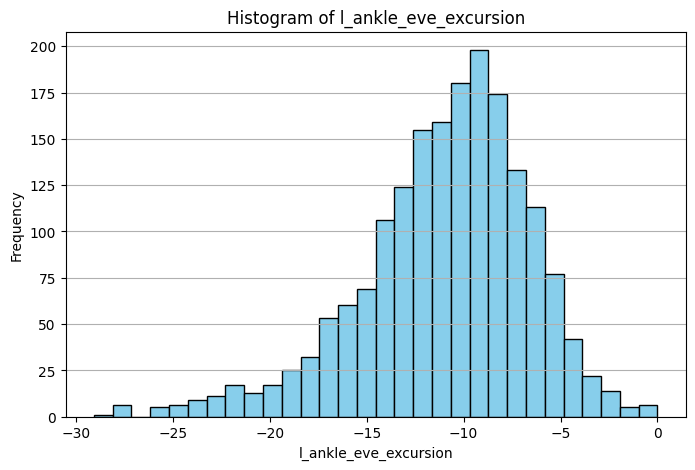

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(X["l_ankle_eve_excursion"].dropna(), bins=30, color='skyblue', edgecolor='black')
plt.title("Histogram of l_ankle_eve_excursion")
plt.xlabel("l_ankle_eve_excursion")
plt.ylabel("Frequency")
plt.grid(axis='y')
plt.show()


In [5]:
# Prepare the dataset for Machine Learning algorithms:
feature_numerical_columns = X.select_dtypes(include=[np.number]).columns.tolist()
feature_categorical_columns = X.select_dtypes(include=['object']).columns.tolist()

if len(X.columns) != (len(feature_numerical_columns) + len(feature_categorical_columns)):
       raise TypeError("You have missed a variable! Check the types")

print("Categorical features:")
print(feature_categorical_columns)
print("Numerical features:")
print(feature_numerical_columns)

Categorical features:
['Gender', 'DominantLeg', 'Level']
Numerical features:
['speed_r', 'age', 'Height', 'Weight', 'YrsRunning', 'NumRaces', 'l_step_width', 'l_stride_rate', 'l_stride_length', 'l_swing_time', 'l_stance_time', 'l_pelvis_peak_drop_angle', 'l_pelvis_drop_excursion', 'l_ankle_df_peak_angle', 'l_ankle_eve_peak_angle', 'l_ankle_eve_percent_stance', 'l_ankle_eve_excursion', 'l_ankle_rot_peak_angle', 'l_ankle_rot_excursion', 'l_knee_flex_peak_angle', 'l_knee_add_peak_angle', 'l_knee_add_excursion', 'l_knee_abd_peak_angle', 'l_knee_abd_excursion', 'l_knee_rot_peak_angle', 'l_knee_rot_excursion', 'l_hip_ext_peak_angle', 'l_hip_add_peak_angle', 'l_hip_add_excursion', 'l_hip_rot_peak_angle', 'l_hip_rot_excursion', 'l_foot_prog_angle', 'l_foot_ang_at_hs', 'l_mhw_exc_from_to', 'l_ankle_eve_peak_vel', 'l_ankle_rot_peak_vel', 'l_knee_abd_peak_vel', 'l_knee_add_peak_vel', 'l_hip_abd_peak_vel', 'l_knee_rot_peak_vel', 'l_hip_rot_peak_vel', 'l_pronation_onset', 'l_pronation_offset', 'l_p

In [6]:
# ## Version 1:
# categorical_data = pd.get_dummies(X[feature_categorical_columns].fillna("unknown"))
# categorical_data.columns
# # Create one-hot encoded features for categorical columns
# categorical_data = pd.get_dummies(X[feature_categorical_columns].fillna("unknown"))

# # We need to remove one category from each group to avoid multicollinearity - We will need to have this into consideration when interpreting the results.
# # categorical_data.rename(columns={
# #     "Gender_female": "gender_is_female",
# #     "Gender_unknown": "gender_is_unknown",
# #     "Level_competitive": "level_is_competitive",
# #     }, inplace=True)
# categorical_data.drop(columns=["Gender_unknown", "DominantLeg_unknown", "Level_unknown"], inplace=True)


# # Standardize the numerical features
# X_numerical = X[feature_numerical_columns].fillna(0)
# scaler = StandardScaler()
# X_numerical_scaled = scaler.fit_transform(X_numerical)
# X_numerical_scaled_df = pd.DataFrame(X_numerical_scaled, columns=feature_numerical_columns, index=X.index)

# # Concatenate standardized numerical and one-hot encoded categorical features
# X_combined = pd.concat([X_numerical_scaled_df, categorical_data], axis=1)

# print(f"Numerical features: {len(feature_numerical_columns)}")
# print(f"Categorical features (after one-hot encoding): {categorical_data.shape[1]}")
# print(f"Total features: {X_combined.shape[1]}")
# # Display all columns of the dataframe
# print("Columns:")
# for i, col in enumerate(X_combined.columns, 1):
#     print(f"{i:3d}. {col}")
# display(X_combined)

In [7]:
## Version 2:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

x_cols = X.columns

cat_cols = feature_categorical_columns  # ['Gender', 'DominantLeg', 'Level']
num_cols = [c for c in X.columns if c not in cat_cols]

imputer = ColumnTransformer(
    transformers=[
        ('impute_num', SimpleImputer(strategy='median', copy=True), num_cols),
        ('impute_cat', SimpleImputer(strategy='constant', fill_value="unknown", copy=True), cat_cols)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_imputed = imputer.fit_transform(X, Y)
X_imputed_df = pd.DataFrame(X_imputed, columns=imputer.get_feature_names_out(), index=X.index)


preprocessing = ColumnTransformer(
        transformers=[
            ('scale_num', StandardScaler(), num_cols),
            ('encode_cat', OneHotEncoder(drop="if_binary", handle_unknown="ignore"), cat_cols)
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
    )

X_prep = preprocessing.fit_transform(X_imputed_df, Y)
X_combined = pd.DataFrame(X_prep, columns=preprocessing.get_feature_names_out(), index=X.index).drop(columns=[col + "_unknown" for col in cat_cols])
display(X_combined)


,speed_r,age,Height,Weight,YrsRunning,NumRaces,l_step_width,l_stride_rate,l_stride_length,l_swing_time,...,r_peak_hip_add_velocity,r_peak_pelvic_drop_velocity,r_vertical_oscillation,Gender_female,Gender_male,DominantLeg_ambidextrous,DominantLeg_left,DominantLeg_right,Level_competitive,Level_recreational
id,,,,,,,,,,,,,,,,,,,,,
100433_20101005T132240,-2.406926,1.232956,0.045388,-0.087876,0.370320,-0.124719,-0.307243,0.000986,-2.622528,-0.338913,...,-1.743700,0.239058,-2.149309,0.0,0.0,0.0,0.0,0.0,0.0,1.0
100434_20101117T132240,-1.095016,1.068010,0.045388,-0.087876,1.214620,-0.124719,-1.831460,0.886585,-1.458975,-0.466027,...,0.764244,-0.390267,-1.504414,1.0,0.0,0.0,0.0,0.0,0.0,1.0
100537_20120703T102550,-1.325076,-0.086615,0.072581,-0.200098,-0.956438,-0.124719,-0.037324,-0.643565,-1.241474,-0.084685,...,2.255015,0.604189,-0.347673,1.0,0.0,0.0,0.0,1.0,0.0,1.0
100560_20120717T103748,-0.215279,-0.416508,0.746976,0.952054,-0.232752,-0.124719,0.677045,-1.610390,0.439240,-1.165155,...,3.526927,-1.746297,1.432837,1.0,0.0,0.0,0.0,1.0,0.0,1.0
101481_20120717T105021,-0.282875,-0.498981,0.420656,-0.873434,-0.232752,-0.124719,0.104643,-0.746010,-0.016982,-0.148242,...,0.475554,1.000454,0.680932,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200986_20150312T143944,4.433200,-1.488659,0.170477,-1.008102,-0.232752,-1.488804,0.298318,0.113669,4.753163,0.169543,...,-0.655317,1.410128,-0.178981,1.0,0.0,0.0,0.0,1.0,1.0,0.0
200987_20150312T160840,0.010181,0.985537,-0.917256,-0.768693,0.732163,-1.147783,0.624754,1.075236,-0.383200,-0.211799,...,0.528663,0.376153,-1.134611,1.0,0.0,0.0,0.0,1.0,0.0,1.0
201100_20150409T155915,0.064515,1.150483,-0.264616,0.727609,2.420764,-1.488804,1.508322,-1.333275,0.645295,0.805114,...,1.170144,-1.120846,-0.052821,0.0,1.0,0.0,0.0,1.0,0.0,1.0


In [8]:
X_combined.to_csv(c.RICKD_BASELINE_X_FILE_V2, index=True)
Y.to_csv(c.RICKD_BASELINE_Y_FILE_V2, index=True)

In [9]:
# Apply t-SNE with same values as  5.1 attempt
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_combined)
tsne.kl_divergence_

/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning

2.018052816390991

In [10]:
# Grid search for best t-SNE perplexity (minimizing kl_divergence_)
perplexity_values = [5, 10, 20, 30, 40, 50, 60]
kl_divergences = []

print("Grid search for t-SNE perplexity:")
for perplexity in perplexity_values:
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, n_iter=1000)
    X_tsne_tmp = tsne.fit_transform(X_combined)
    kl = tsne.kl_divergence_
    kl_divergences.append(kl)
    print(f"Perplexity: {perplexity:2d} | KL Divergence: {kl:.6f}")

best_idx = int(np.argmin(kl_divergences))
best_perplexity = perplexity_values[best_idx]
best_kl = kl_divergences[best_idx]
print(f"\nBest perplexity: {best_perplexity} (KL Divergence: {best_kl:.6f})")


Grid search for t-SNE perplexity:


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning

Perplexity:  5 | KL Divergence: 1.835922


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning

Perplexity: 10 | KL Divergence: 2.070365


...

Perplexity: 40 | KL Divergence: 1.940821


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning

Perplexity: 50 | KL Divergence: 1.885710


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning

Perplexity: 60 | KL Divergence: 1.826504

Best perplexity: 60 (KL Divergence: 1.826504)


In [11]:
# Apply t-SNE with best perplexity vlaue.
print(f"Running t-SNE with best perplexity value. Value: {best_perplexity}")
tsne = TSNE(n_components=2, random_state=42, perplexity=best_perplexity, n_iter=1000)
X_tsne = tsne.fit_transform(X_combined)
tsne.kl_divergence_

Running t-SNE with best perplexity value. Value: 60


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning

1.826503872871399

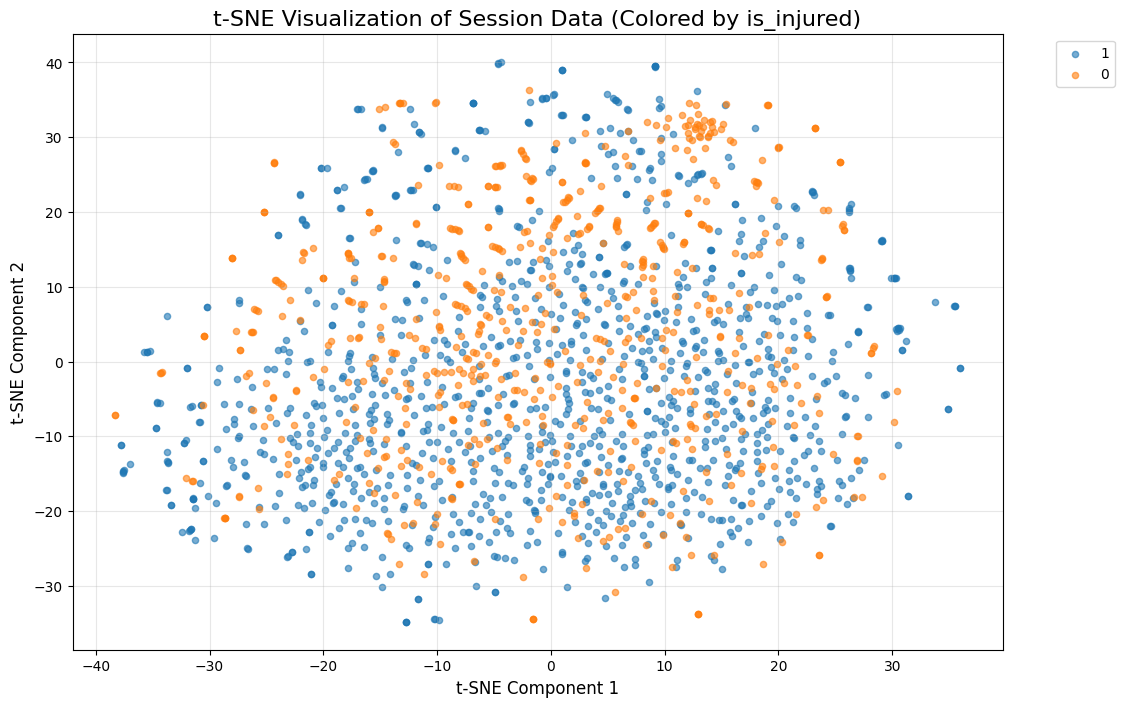

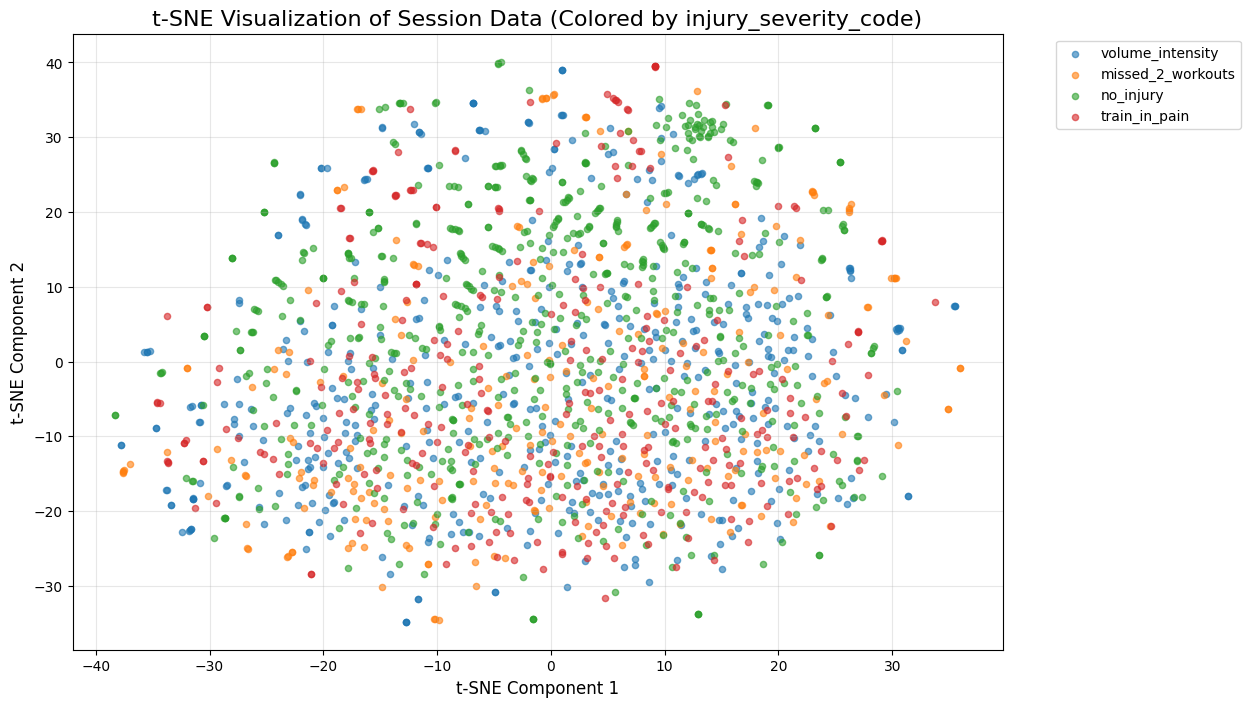

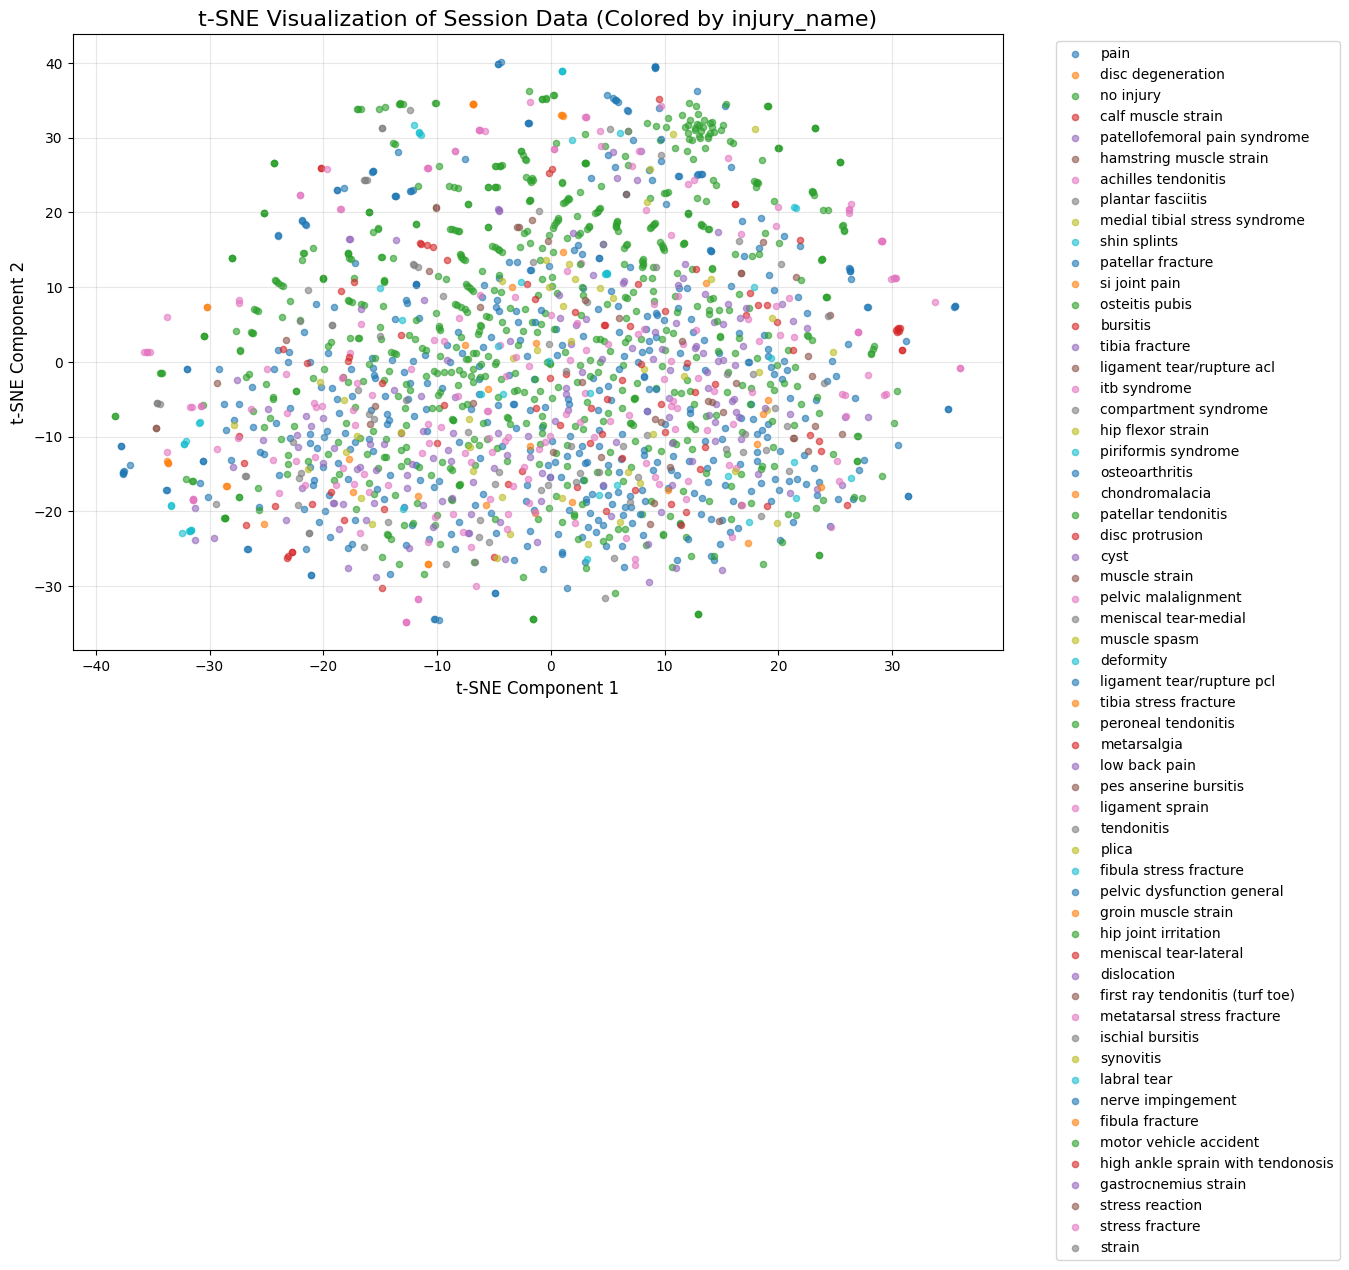

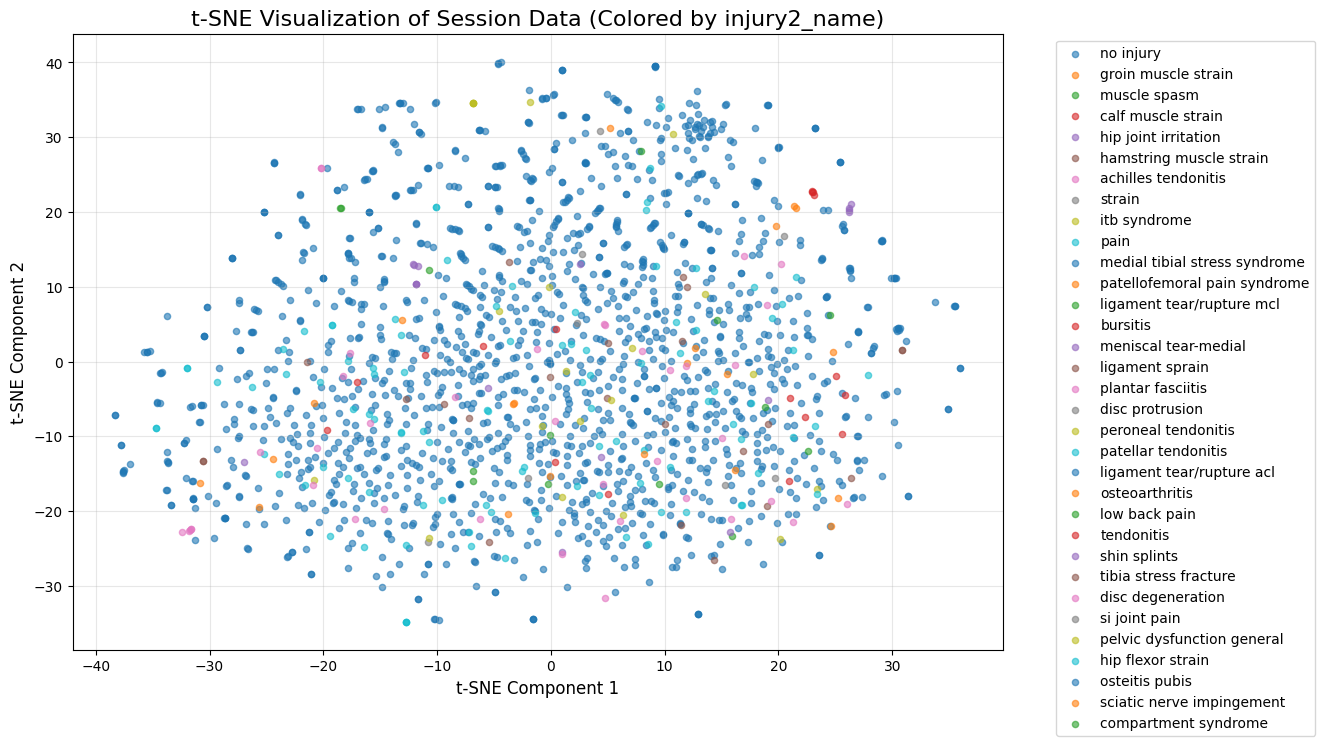

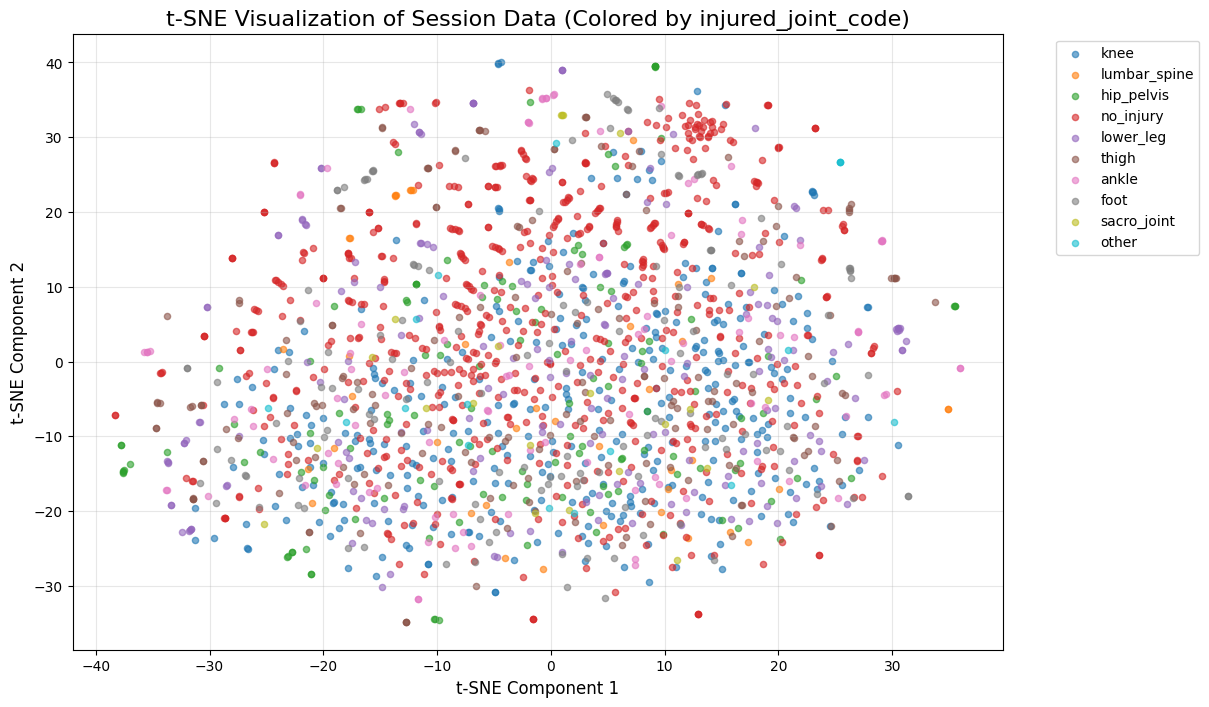

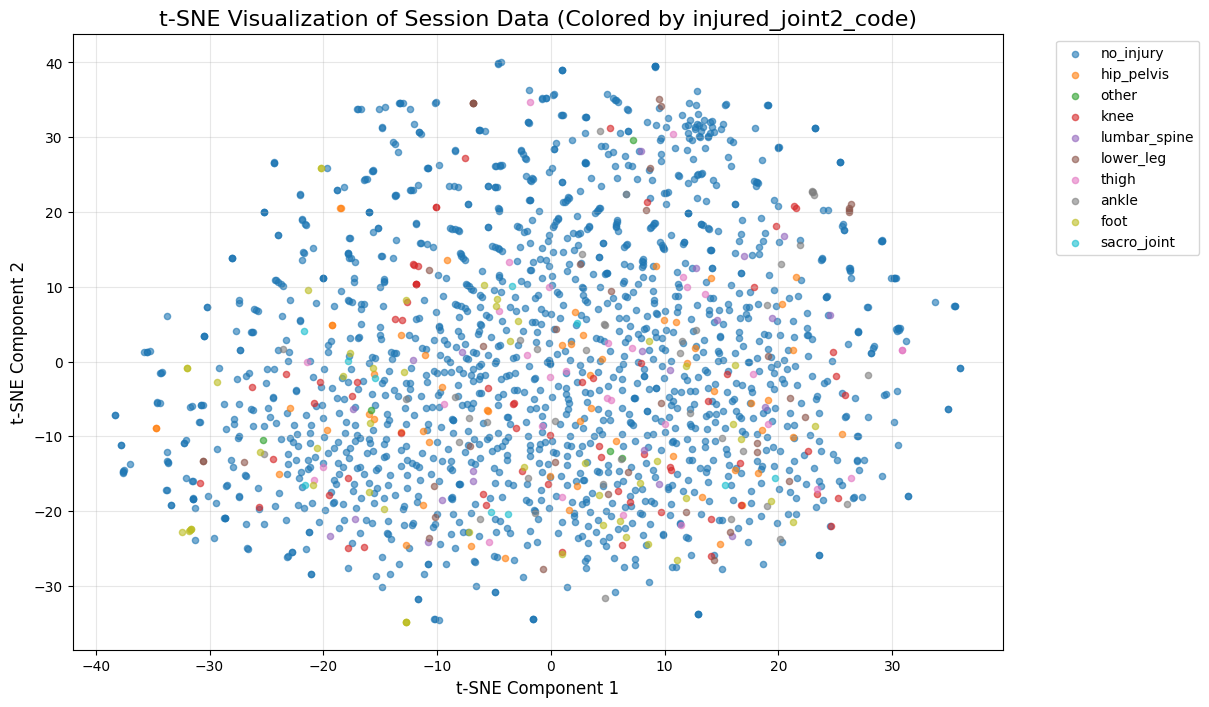

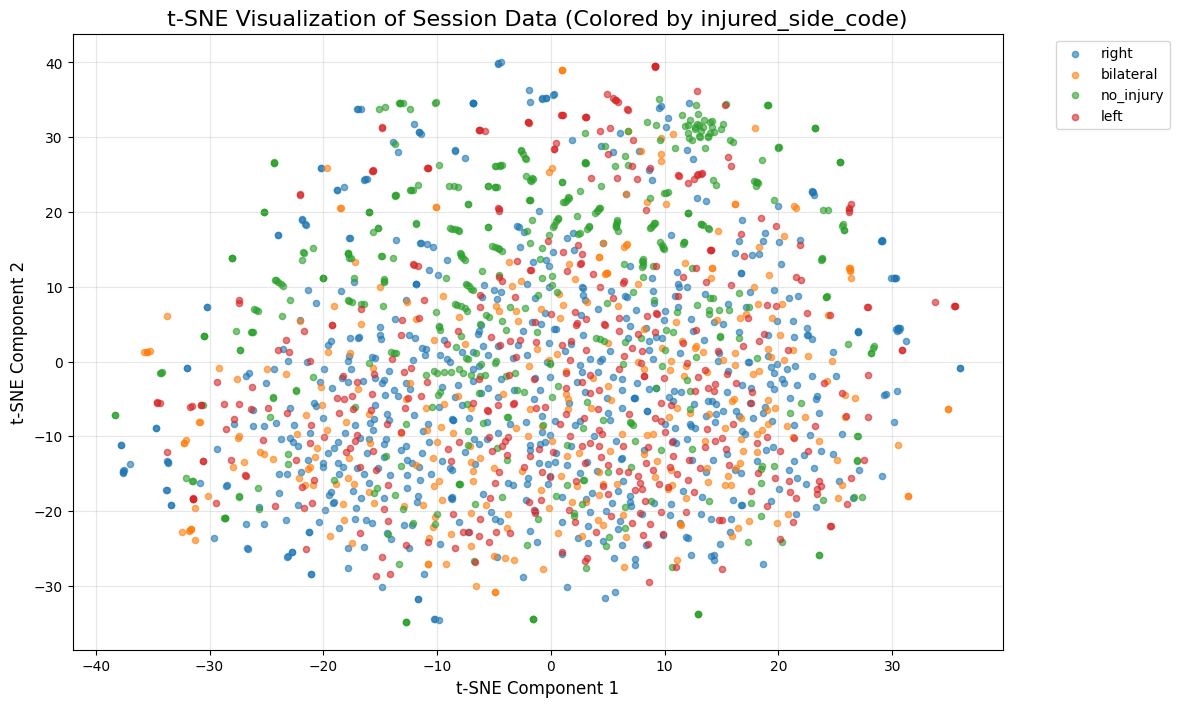

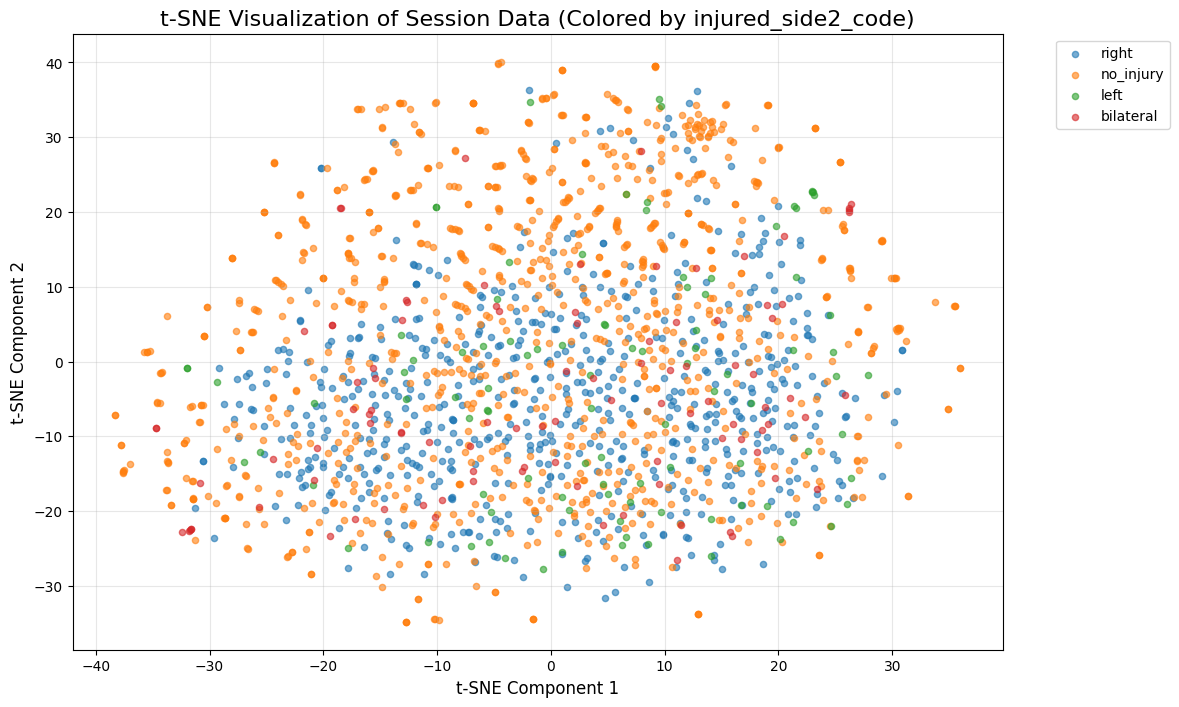

In [12]:
def plot_model_outputs_scatter_by_column(
    model_output, 
    data, 
    column_name, 
    model_name,
    figsize=(12, 8),
    drop_values=None
):
    """
    Create Model Outputs visualization colored by a specific column.
    
    Parameters:
    model_output: Model Outputs array; Expected shape (N,2)
    data: DataFrame containing the column to color by
    column_name: Name of the column to use for coloring
    model_name: Name of the model to use in the label
    figsize: Figure size tuple
    drop_values: List of values to exclude from the plot
    """
    plt.figure(figsize=figsize)
    
    unique_values = data[column_name].dropna().unique()
    if drop_values is not None:
        unique_values = [v for v in unique_values if v not in drop_values]
    
    for value in unique_values:
        mask = data[column_name] == value
        plt.scatter(model_output[mask, 0], model_output[mask, 1], alpha=0.6, s=20, label=str(value))
    
    plt.title(f'{model_name} Visualization of Session Data (Colored by {column_name})', fontsize=16)
    plt.xlabel(f'{model_name} Component 1', fontsize=12)
    plt.ylabel(f'{model_name} Component 2', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    # plt.tight_layout()
    plt.show()

# Plot visualizations for different columns
columns_to_plot = [
    "is_injured",
    "injury_severity_code",
    "injury_name",
    "injury2_name",
    "injured_joint_code",
    "injured_joint2_code",
    "injured_side_code",
    "injured_side2_code",
]

for column in columns_to_plot:
    if column in session_data_full.columns:
        plot_model_outputs_scatter_by_column(X_tsne, session_data_full, column, "t-SNE")
    else:
        print(f"Column '{column}' not found in the dataset")


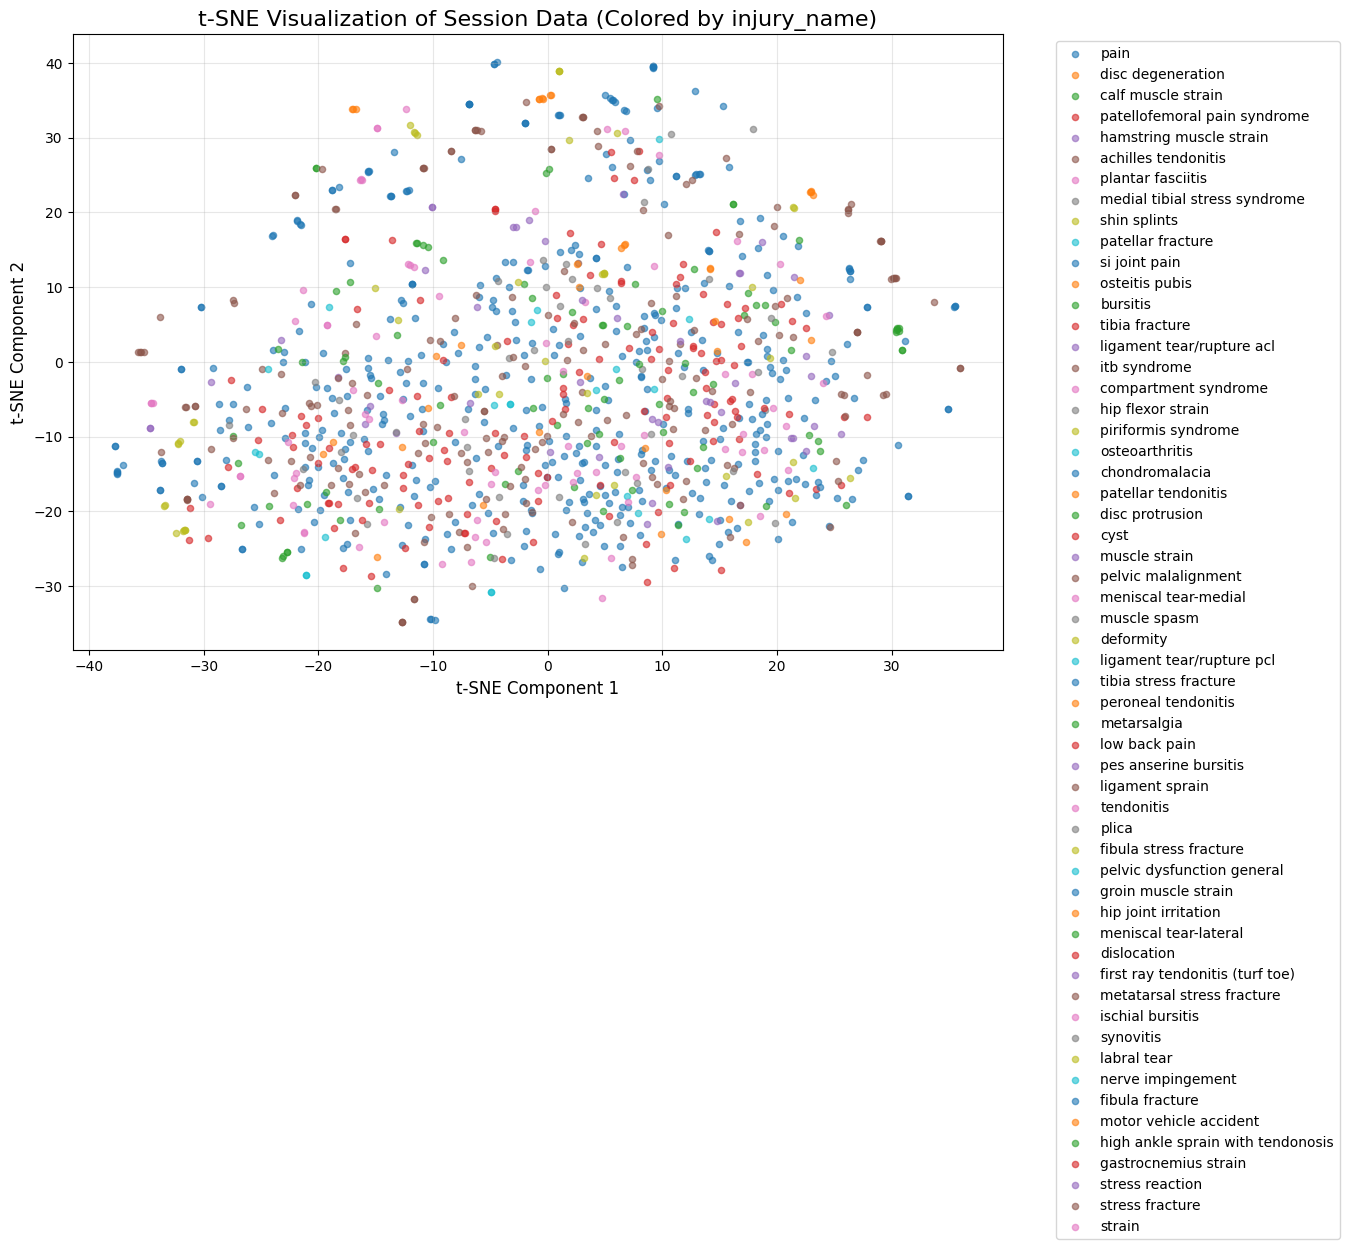

In [13]:
plot_model_outputs_scatter_by_column(X_tsne, session_data_full, "injury_name", "t-SNE", drop_values=["no injury"])

Small group of non-injured samples can be seen, also seems that if we would draw a line in the middle we would have a clasifier slightly better than choosing at random.
Other than that, not much change with previsou iteration.

Let's try with PCA

In [14]:
# Applying PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_combined)
pca.explained_variance_


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmu

array([8.55098274, 8.03394065])

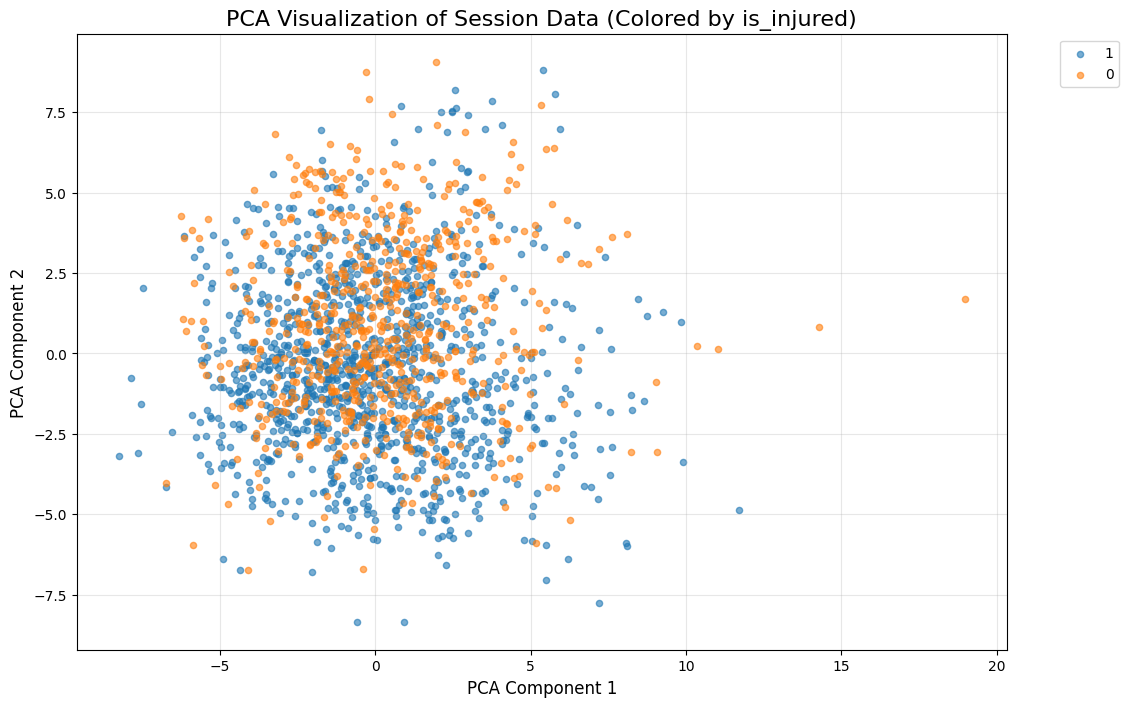

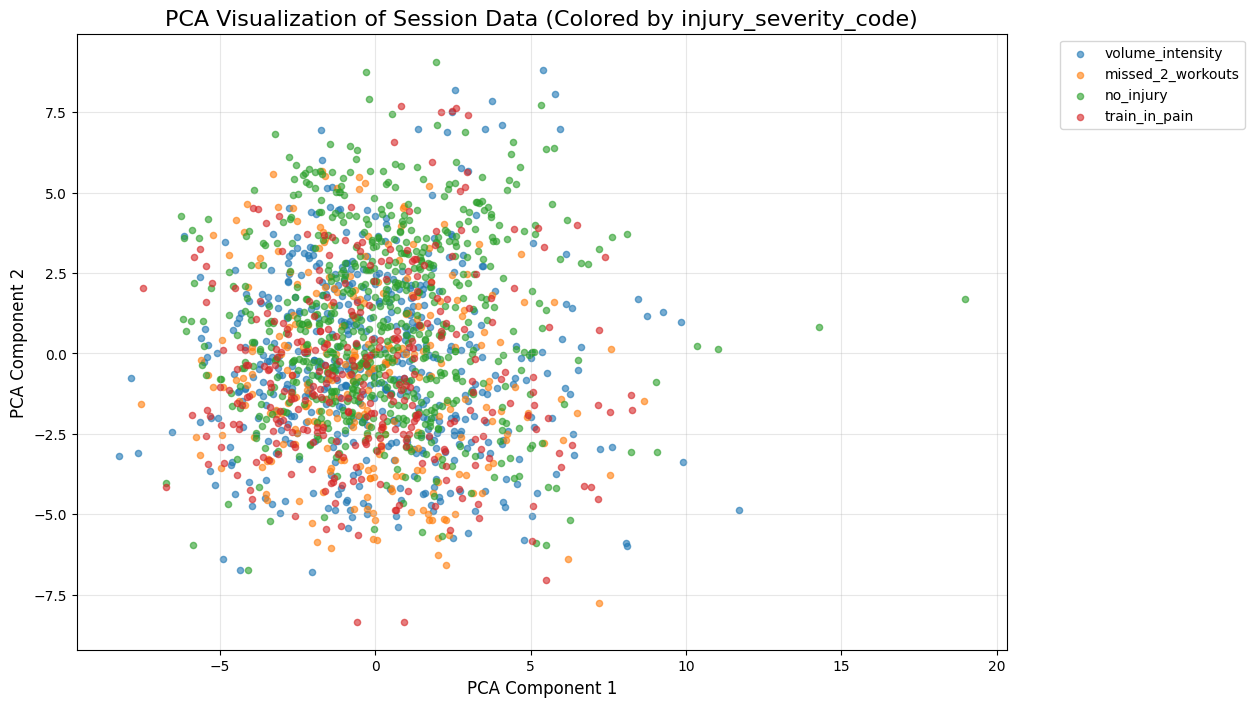

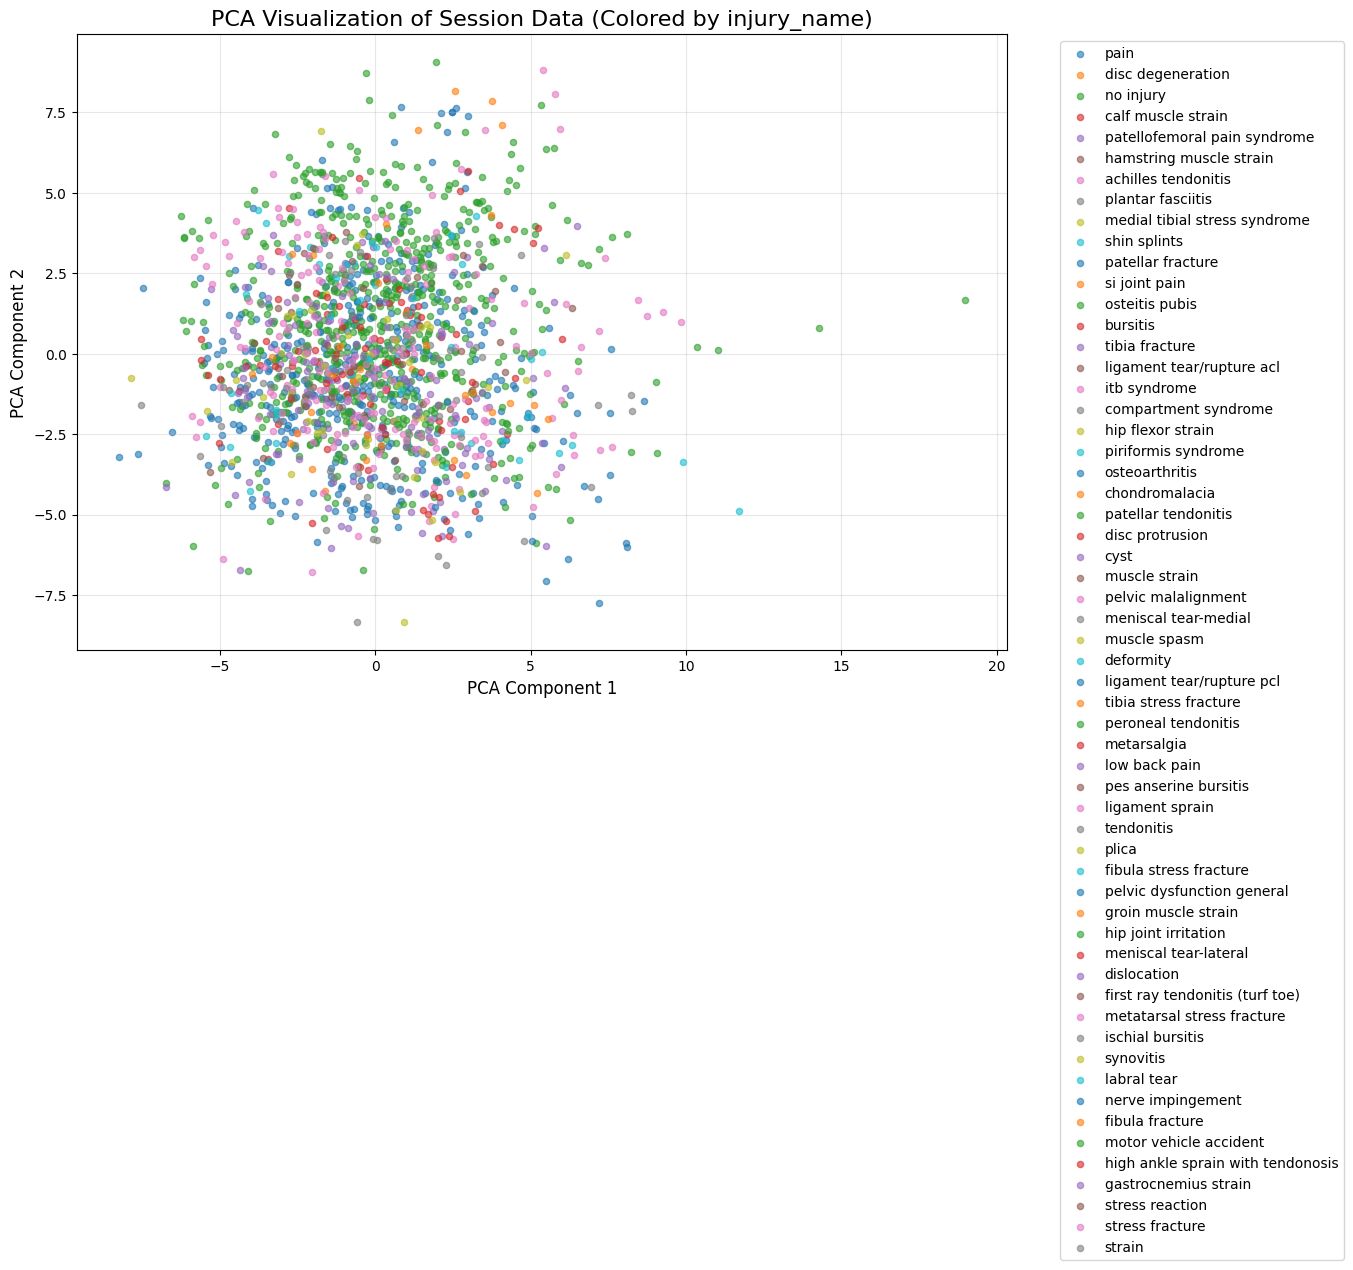

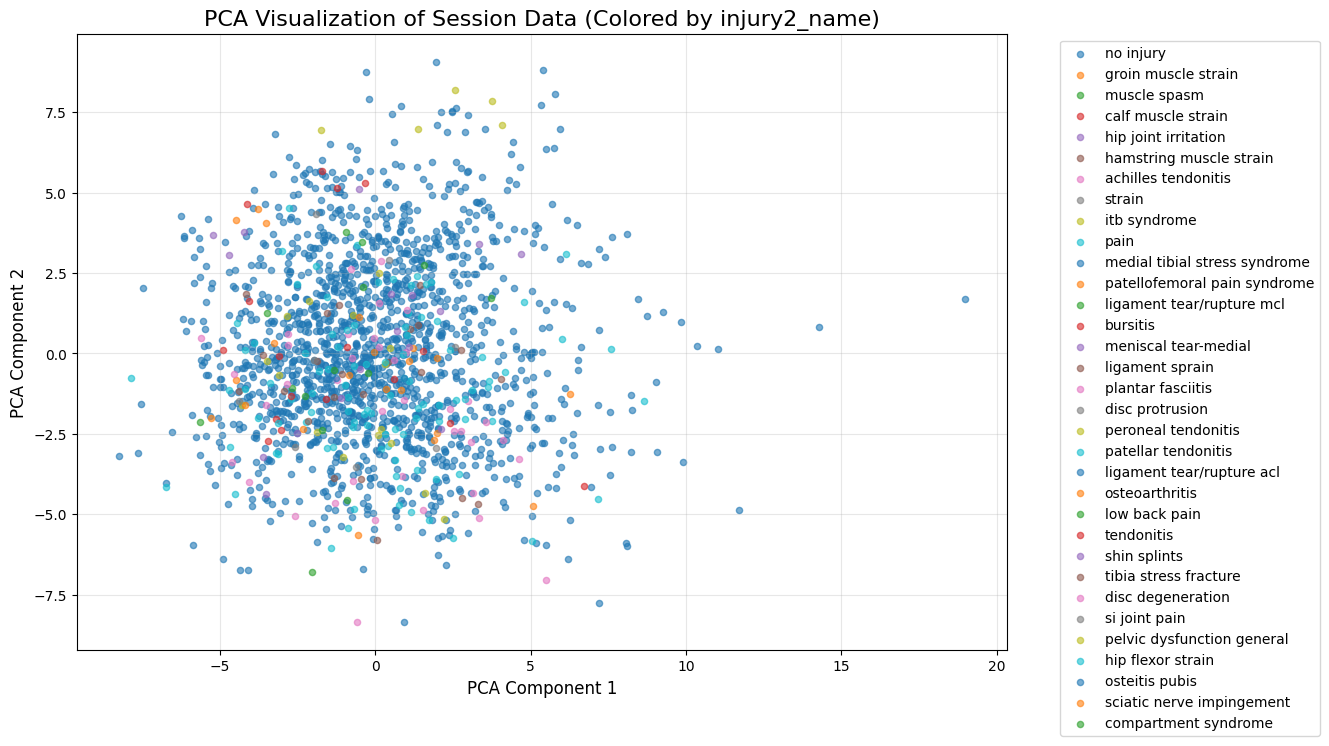

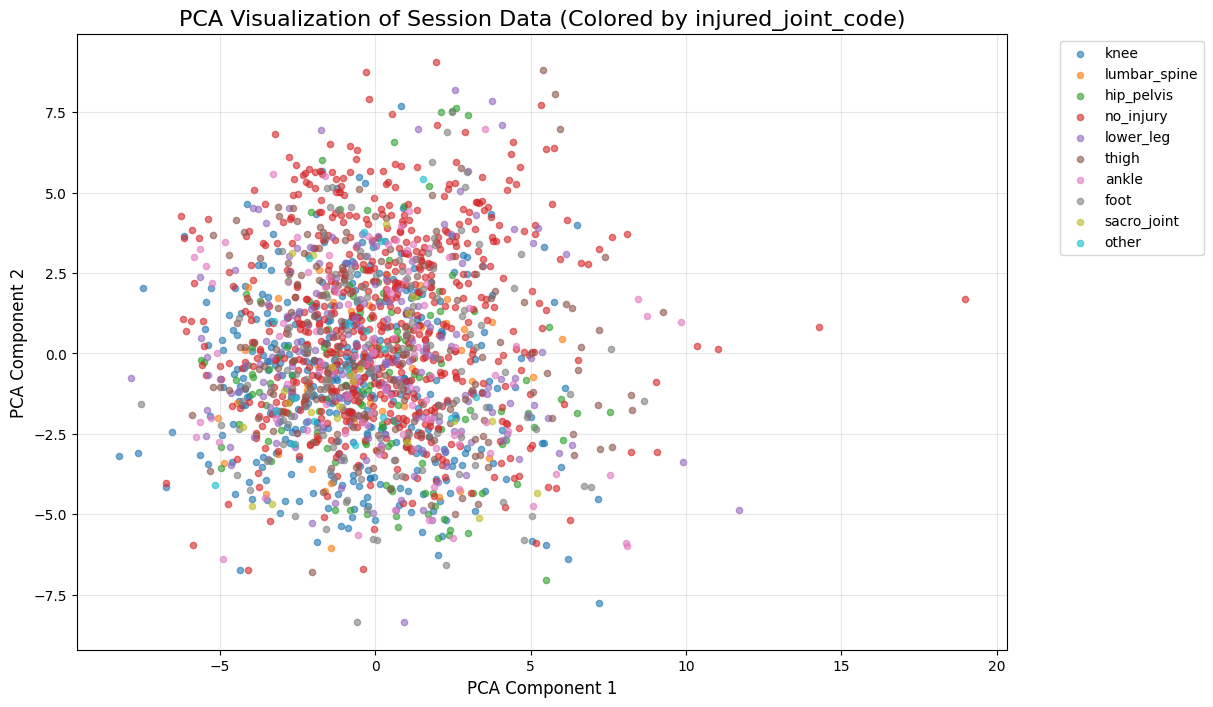

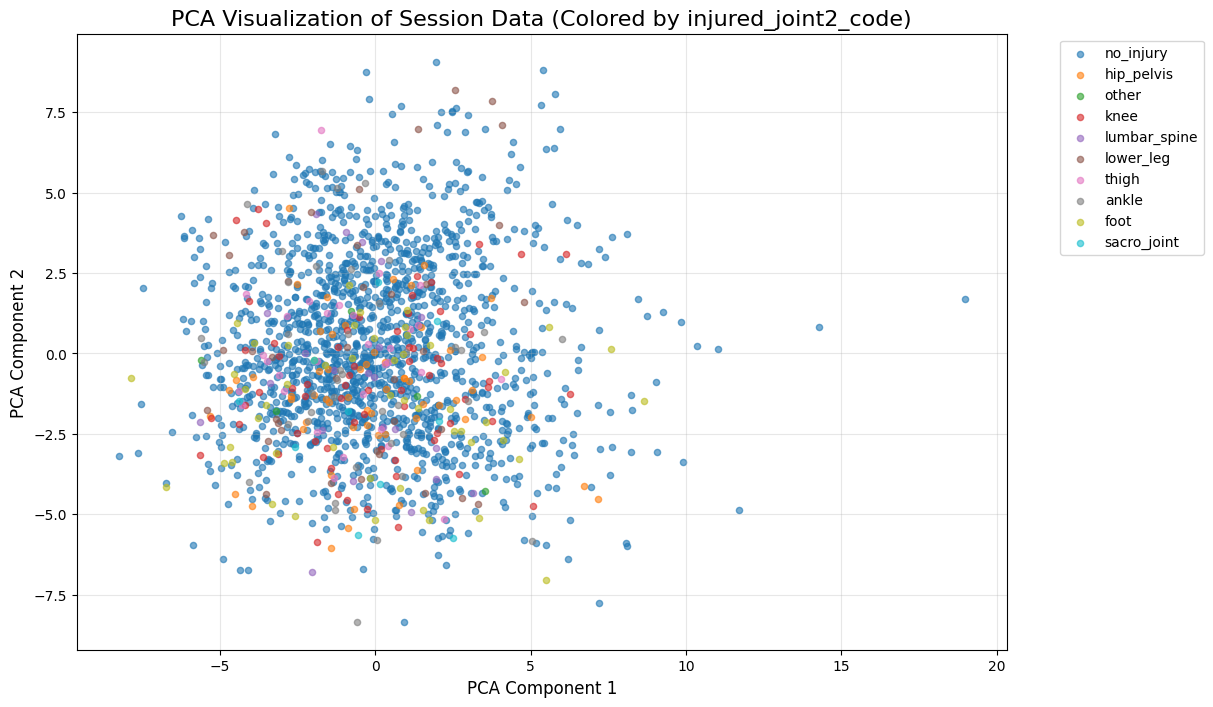

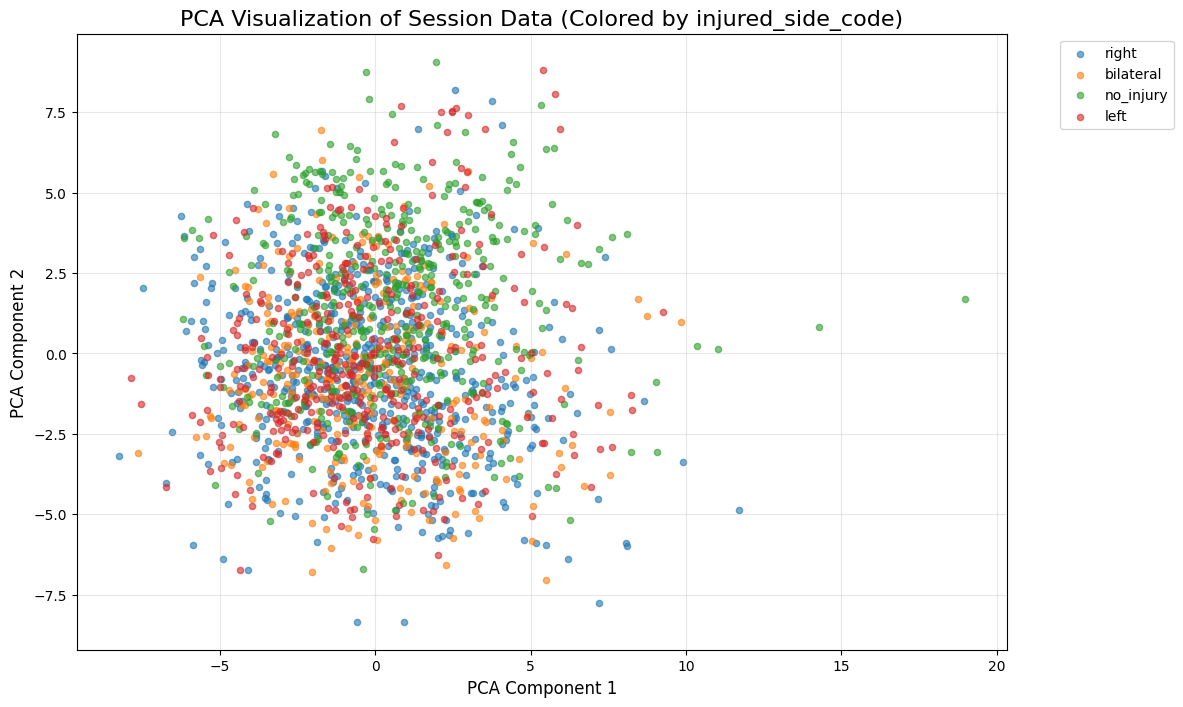

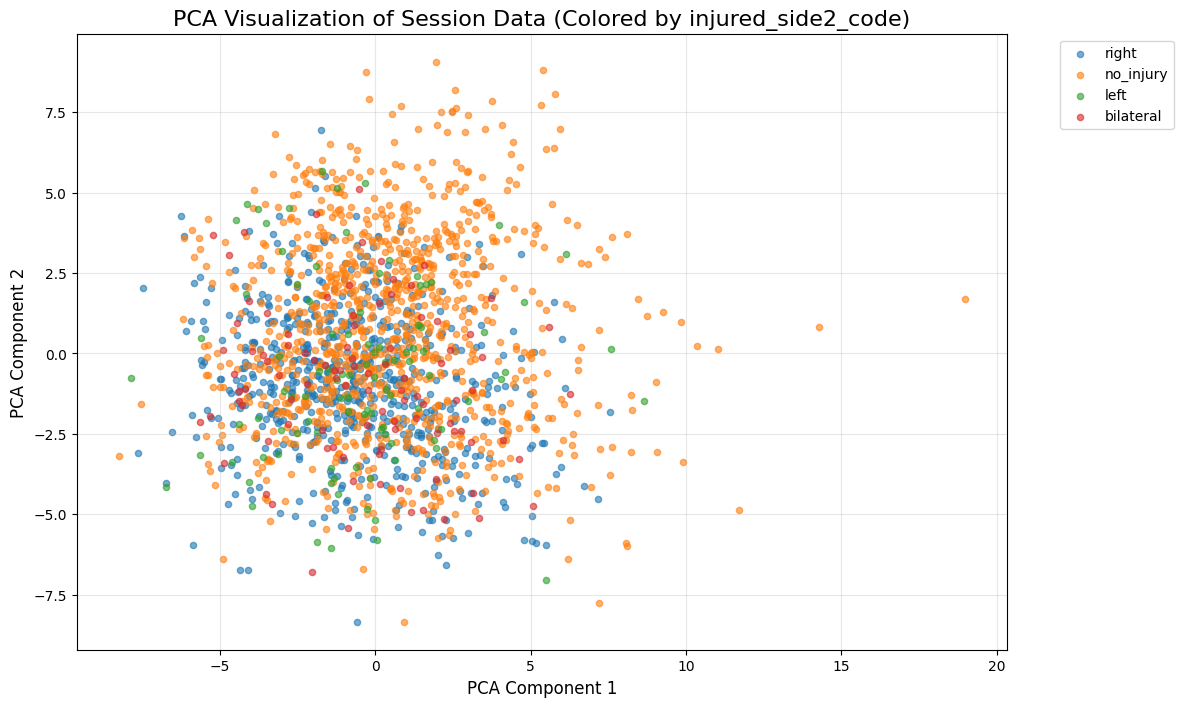

In [15]:
# Plot visualizations for different columns
columns_to_plot = [
    "is_injured",
    "injury_severity_code",
    "injury_name",
    "injury2_name",
    "injured_joint_code",
    "injured_joint2_code",
    "injured_side_code",
    "injured_side2_code",
]

for column in columns_to_plot:
    if column in session_data_full.columns:
        plot_model_outputs_scatter_by_column(X_pca, session_data_full, column, "PCA")
    else:
        print(f"Column '{column}' not found in the dataset")

Now we are going to look at the correlation between is_injured and the rest of the variables:

Top 10 most positively correlated features with is_injured:
r_stance_time            0.222867
l_stance_time            0.218910
r_hip_ext_peak_angle     0.140189
r_ankle_eve_peak_vel     0.139564
l_ankle_eve_peak_vel     0.137646
r_foot_ang_at_hs         0.119876
l_foot_ang_at_hs         0.118026
l_hip_ext_peak_angle     0.117884
l_ankle_eve_excursion    0.109489
l_knee_rot_peak_angle    0.107530
Name: is_injured, dtype: float64

Top 10 most negatively correlated features with is_injured:
r_pelvis_drop_excursion       -0.094219
l_hip_rot_peak_angle          -0.097361
r_stride_rate                 -0.102482
l_stride_rate                 -0.102763
r_knee_abd_peak_angle         -0.111701
r_peak_pelvic_drop_velocity   -0.125055
l_ankle_df_peak_angle         -0.132278
l_stride_length               -0.165498
r_stride_length               -0.165860
speed_r                       -0.186149
Name: is_injured, dtype: float64


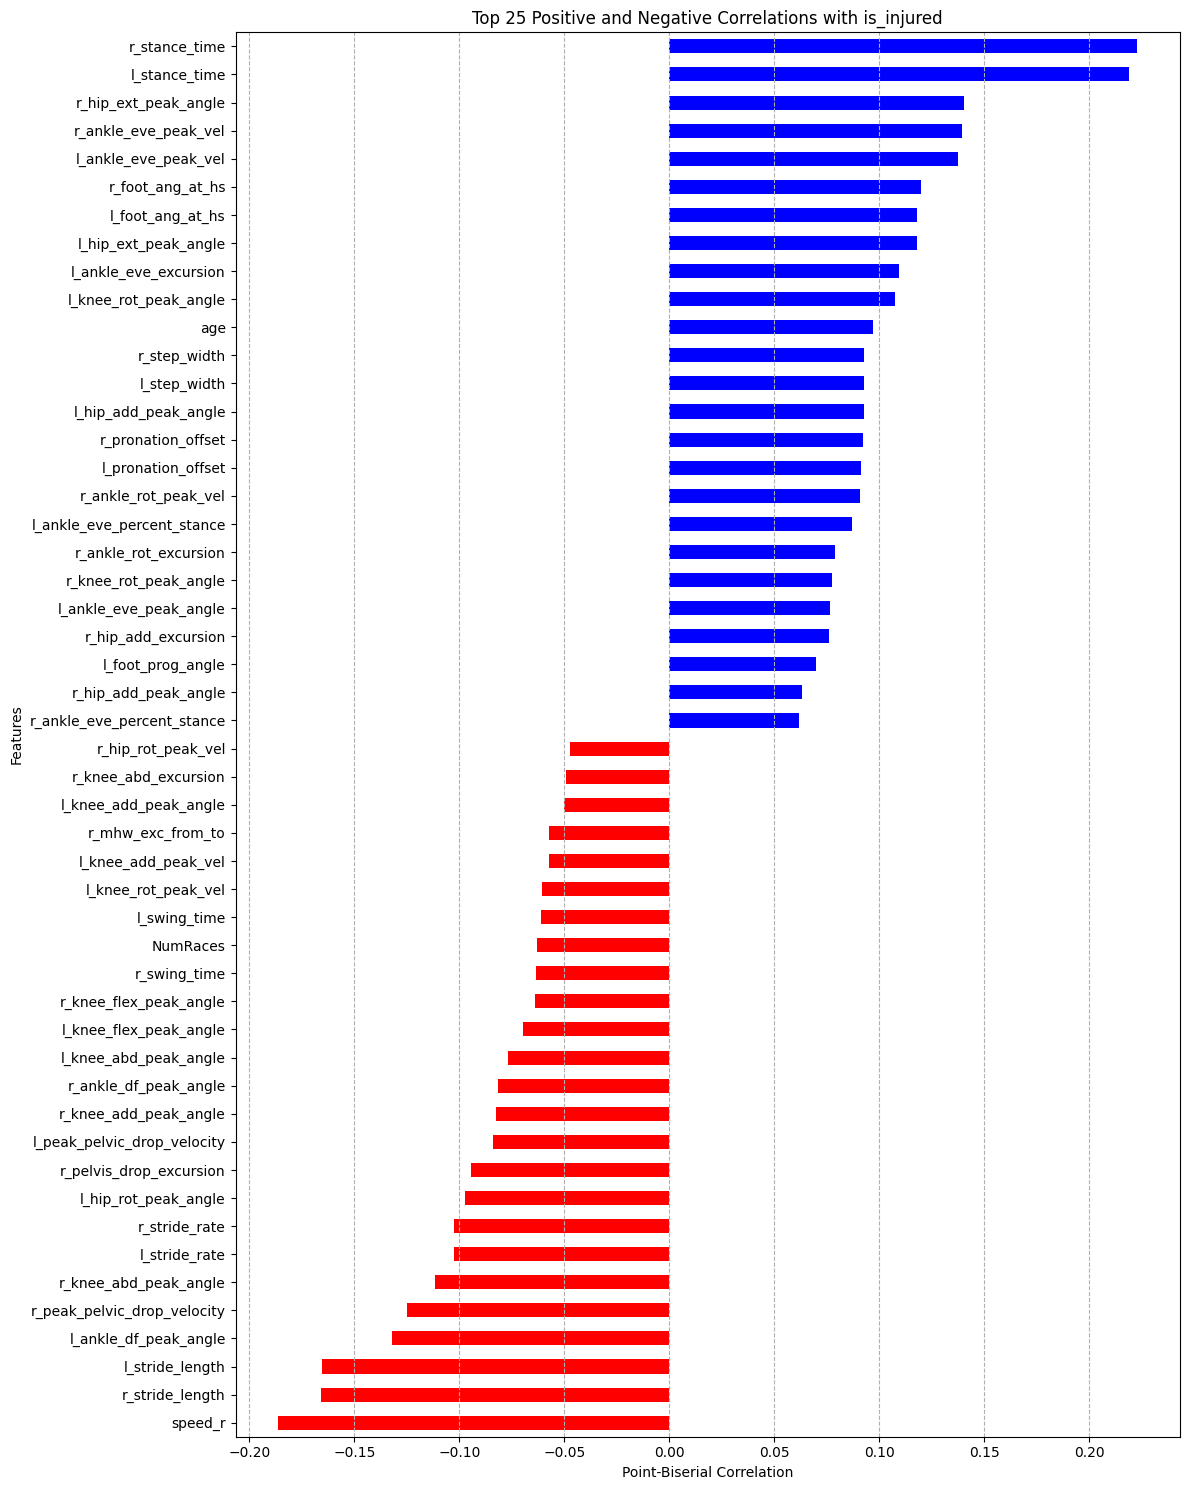

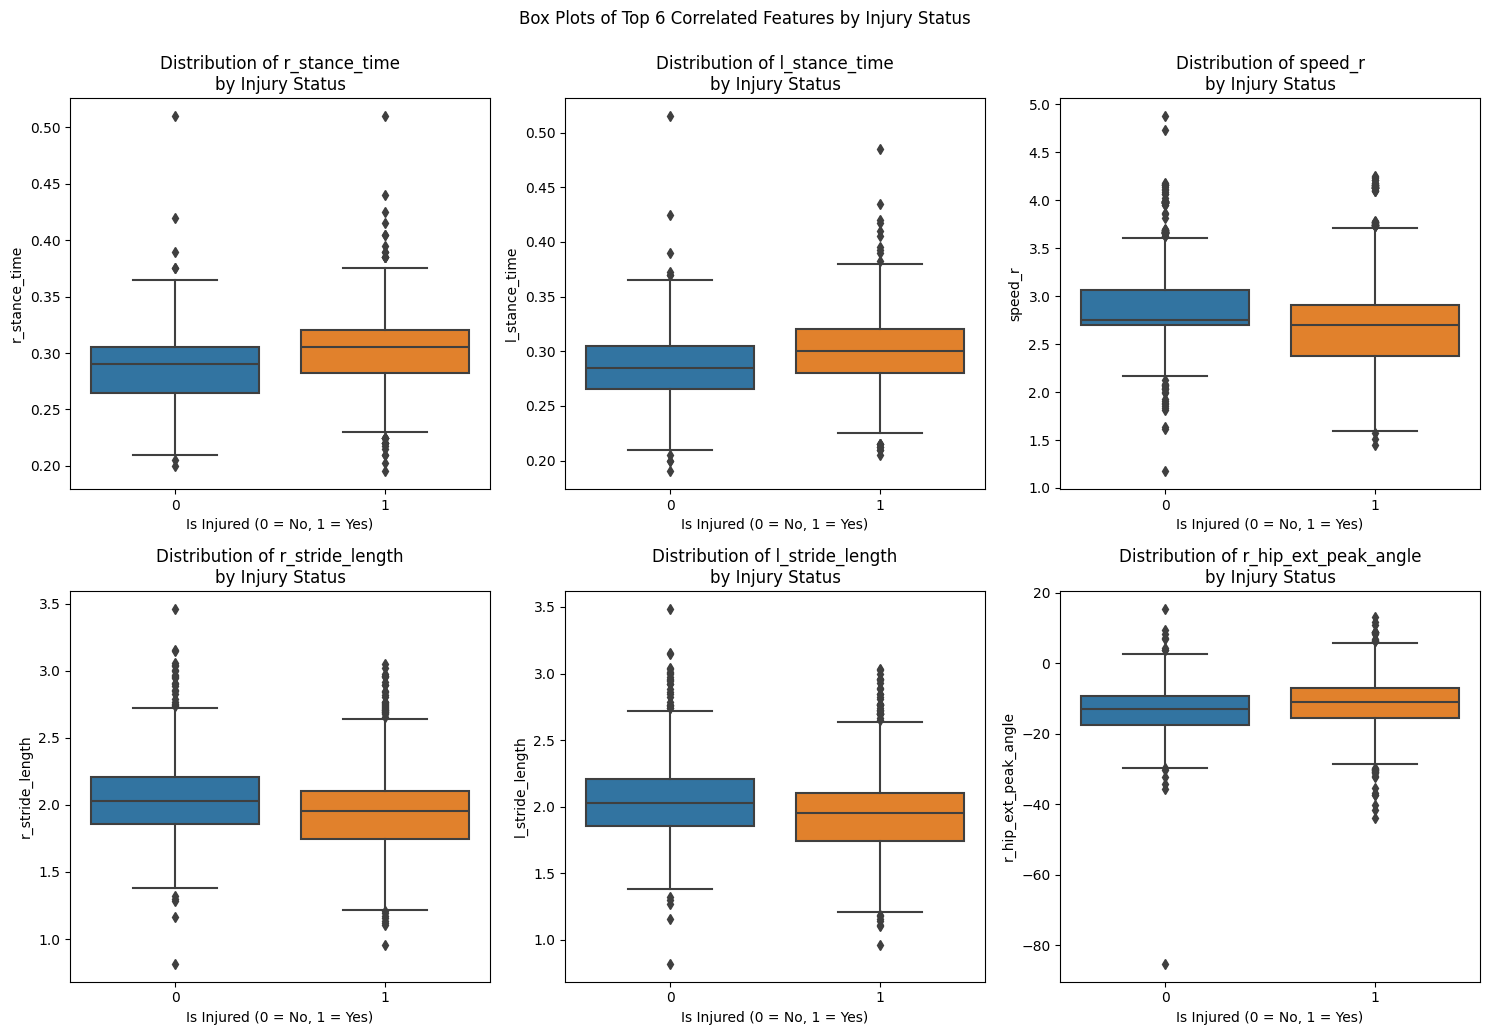


Summary of feature importance (top 20 by absolute correlation):


,Correlation,Abs_Correlation,P_Value,Corr_Rank
r_stance_time,0.222867,0.222867,4.715385e-22,1.0
l_stance_time,0.218910,0.218910,2.577794e-21,2.0
speed_r,-0.186149,0.186149,9.558880e-16,3.0
r_stride_length,-0.165860,0.165860,9.077124e-13,4.0
l_stride_length,-0.165498,0.165498,1.018306e-12,5.0
r_hip_ext_peak_angle,0.140189,0.140189,1.680416e-09,6.0
r_ankle_eve_peak_vel,0.139564,0.139564,1.986523e-09,7.0
l_ankle_eve_peak_vel,0.137646,0.137646,3.305597e-09,8.0
l_ankle_df_peak_angle,-0.132278,0.132278,1.324488e-08,9.0
r_peak_pelvic_drop_velocity,-0.125055,0.125055,7.872206e-08,10.0


In [16]:
import pandas as pd
from scipy.stats import pointbiserialr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

numerical_X = X[feature_numerical_columns].copy()

df_for_corr = numerical_X.copy()
df_for_corr['is_injured'] = Y['is_injured']

correlations = df_for_corr.corr(numeric_only=True)['is_injured'].dropna().sort_values(ascending=False)

# Remove the self-correlation of is_injured
correlations = correlations.drop('is_injured')

# Calculate p-values for correlations
p_values = {}
for col in numerical_X.columns:
    # pointbiserialr doesn't handle NaNs, so we drop them for the calculation
    valid_data = df_for_corr[[col, 'is_injured']].dropna()
    if valid_data.shape[0] > 1:
        corr, p = pointbiserialr(valid_data[col], valid_data['is_injured'])
        p_values[col] = p
p_values = pd.Series(p_values)


print("Top 10 most positively correlated features with is_injured:")
print(correlations.head(10))
print("\nTop 10 most negatively correlated features with is_injured:")
print(correlations.tail(10))

# Horizontal Bar Plot of Correlations
top_25_corr = pd.concat([correlations.head(25), correlations.tail(25)]).sort_values()
plt.figure(figsize=(12, 15))
colors = ['red' if c < 0 else 'blue' for c in top_25_corr.values]
top_25_corr.plot(kind='barh', color=colors)
plt.title('Top 25 Positive and Negative Correlations with is_injured')
plt.xlabel('Point-Biserial Correlation')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--')
plt.tight_layout()
plt.show()

# Box plots for top correlated features
top_6_features = correlations.abs().nlargest(6).index

plt.figure(figsize=(15, 10))
for i, feature in enumerate(top_6_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='is_injured', y=feature, data=df_for_corr)
    plt.title(f'Distribution of {feature}\nby Injury Status')
    plt.xlabel('Is Injured (0 = No, 1 = Yes)')
    plt.ylabel(feature)
plt.tight_layout()
plt.suptitle('Box Plots of Top 6 Correlated Features by Injury Status', y=1.03)
plt.show()

# Summary Table
summary_df = pd.DataFrame({
    'Correlation': correlations,
    'Abs_Correlation': correlations.abs(),
    'P_Value': p_values,
}).sort_values('Abs_Correlation', ascending=False).dropna(subset=['Correlation', 'P_Value'])

summary_df['Corr_Rank'] = summary_df['Abs_Correlation'].rank(ascending=False)

print("\nSummary of feature importance (top 20 by absolute correlation):")
from IPython.display import display
with pd.option_context('display.max_rows', 25):
    display(summary_df.head(20))


In [17]:
# Multicollinearity Analysis

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from IPython.display import display

numerical_X = X[feature_numerical_columns].copy()
numerical_X_imputed = numerical_X.fillna(numerical_X.median())

corr_matrix = numerical_X_imputed.corr().abs()

# Select upper triangle of correlation matrix to avoid duplicate pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find pairs with correlation greater than 0.8
high_corr_pairs = upper.stack().reset_index()
high_corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'] > 0.8].sort_values(by='Correlation', ascending=False)

print("\nPairs of features with absolute correlation > 0.8:")
with pd.option_context('display.max_rows', 20):
    display(high_corr_pairs)

# Variance Inflation Factor (VIF)
# VIF measures how much the variance of an estimated regression coefficient is increased because of multicollinearity.
# A VIF > 10 is often considered a sign of high multicollinearity.

X_for_vif = sm.add_constant(numerical_X_imputed)

print("\nCalculating VIF... (this may take a moment)")

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_for_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_for_vif.values, i) for i in range(len(X_for_vif.columns))]

# Remove the VIF of the constant, which is not a feature
vif_data = vif_data[vif_data['feature'] != 'const'].sort_values('VIF', ascending=False)

print("\nTop 20 Features by VIF:")
with pd.option_context('display.max_rows', 20):
    display(vif_data.head(20))

save_df_as_table_image(
    vif_data[vif_data['VIF'] > 5],
    os.path.join(c.RICKD_RESULTS_FOLDER, 'vif_session_data_full_features_gt_5.png')
)

print(f"\n{len(vif_data[vif_data['VIF'] > 10])} features have VIF > 10 (High Multicollinearity).")
print(f"{len(vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)])} features have VIF between 5 and 10 (Moderate Multicollinearity).")


Pairs of features with absolute correlation > 0.8:


,Feature 1,Feature 2,Correlation
534,l_step_width,r_step_width,1.000000
691,l_stride_length,r_stride_length,0.999814
613,l_stride_rate,r_stride_rate,0.998800
768,l_swing_time,r_swing_time,0.937379
47,speed_r,r_stride_length,0.930643
7,speed_r,l_stride_length,0.930306
2263,l_foot_ang_at_hs,r_foot_ang_at_hs,0.908562
844,l_stance_time,r_stance_time,0.908525
1924,l_hip_ext_peak_angle,r_hip_ext_peak_angle,0.883064
2874,l_vertical_oscillation,r_vertical_oscillation,0.862028



Calculating VIF... (this may take a moment)


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



Top 20 Features by VIF:


,feature,VIF
47,r_step_width,inf
7,l_step_width,inf
49,r_stride_length,7.706292e+04
9,l_stride_length,7.702024e+04
8,l_stride_rate,1.213412e+04
48,r_stride_rate,1.201502e+04
23,l_knee_abd_peak_angle,9.250087e+02
21,l_knee_add_peak_angle,8.193304e+02
63,r_knee_abd_peak_angle,8.123570e+02
61,r_knee_add_peak_angle,5.887614e+02



33 features have VIF > 10 (High Multicollinearity).
19 features have VIF between 5 and 10 (Moderate Multicollinearity).
